#### **Этап 1. Загрузка и подготовка данных**
Скачайте или используйте предоставленный набор данных botsv1, содержащий логи WinEventLog и DNS.  
Загрузите данные в датафреймы с помощью Pandas.  
При необходимости выполните нормализацию данных: приведение к единому формату, очистку.

In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sys import exit

In [12]:
def load_and_normalize_data(file_path: str) -> pd.DataFrame:
    """
    Загружает JSON, извлекает полезную нагрузку из поля 'result'
    и возвращает нормализованный DataFrame.
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Извлекаем данные, пропуская метаданные (offset, preview)
        # Проверяем, есть ли ключ 'result' (структура Splunk JSON)
        extracted_data = [item.get('result', {}) for item in data if 'result' in item]
        
        if not extracted_data:
            print("[-] В файле не найдено записей с ключом 'result'.")
            return pd.DataFrame()

        df = pd.DataFrame(extracted_data)
        
        # Приводим коды событий к строке для надежного сравнения
        if 'EventCode' in df.columns:
            df['EventCode'] = df['EventCode'].astype(str)
            
        print(f"[+] Данные загружены. Строк: {len(df)}")
        return df

    except FileNotFoundError:
        print(f"[-] Файл {file_path} не найден.")
        return pd.DataFrame()
    except json.JSONDecodeError:
        print("[-] Ошибка структуры JSON.")
        return pd.DataFrame()
    except Exception as e:
        print(f"[-] Ошибка при загрузке: {e}")
        return pd.DataFrame()

#### Этап 2. Анализ данных
Проанализируйте два типа логов:
1) Для WinEventLog найдите подозрительные события по полю EventID, например, входы с ошибками, эскалация привилегий и прочие;
2) для DNS-логов определите потенциально вредоносные или подозрительные запросы, например, частые обращения к редким доменам, нестандартные поддомены.

In [13]:
def get_threat_label(row: pd.Series) -> str:
    """
    Вспомогательная функция для маркировки типа угрозы.
    Используется внутри apply().
    """
    code = str(row.get('EventCode', ''))
    # Приведение к нижнему регистру для поиска подстрок
    proc_name = str(row.get('New_Process_Name', '')).lower()
    command_line = str(row.get('Process_Command_Line', '')).lower()

    if code == '4625':
        return 'Failed Logon (4625)'
    
    # 4688: Создание процесса. Ищем PowerShell или CMD
    if code == '4688':
        if 'powershell' in proc_name or 'powershell' in command_line:
            return 'PowerShell Execution (4688)'
        if 'cmd.exe' in proc_name:
            return 'CMD Execution (4688)'
        return 'Process Creation (4688)'
        
    if code == '4703':
        return 'Token Right Adjusted (4703)'
    if code == '4720':
        return 'User Created (4720)'
    if code == '1102':
        return 'Audit Log Cleared (1102)'
    if code == '4656':
        return 'Handle Requested (4656)'
    
    return f'Suspicious Event ({code})'

In [14]:
def find_suspicious_windows_events(df: pd.DataFrame) -> pd.DataFrame:
    """
    Фильтрует DataFrame на наличие подозрительных событий Windows.
    """
    if df.empty or 'EventCode' not in df.columns:
        return pd.DataFrame()

    # Список интересующих EventID
    suspicious_codes = ['4625', '4720', '1102', '4703', '4656', '4688']
    
    # Базовая фильтрация по коду
    mask = df['EventCode'].isin(suspicious_codes)
    suspicious_df = df[mask].copy()

    # Если событий нет, возвращаем пустой DF
    if suspicious_df.empty:
        return pd.DataFrame()

    # Применяем функцию маркировки для создания понятного описания угрозы
    suspicious_df['Threat_Type'] = suspicious_df.apply(get_threat_label, axis=1)
    
    return suspicious_df

In [15]:
def find_suspicious_dns_events(df: pd.DataFrame) -> pd.DataFrame:
    """
    Анализирует DNS события (если они есть).
    Критерий: очень длинные запросы (потенциальный туннелинг).
    """
    if df.empty:
        return pd.DataFrame()
    
    dns_df = pd.DataFrame()

    # Пытаемся найти DNS-записи по наличию поля 'query' или 'source'
    if 'query' in df.columns:
        # Фильтруем только те строки, где есть запрос
        dns_candidates = df[df['query'].notna()].copy()
        
        # Условие: длина домена > 50 символов
        mask_long = dns_candidates['query'].str.len() > 50
        dns_df = dns_candidates[mask_long].copy()
        
        if not dns_df.empty:
            dns_df['Threat_Type'] = 'Long DNS Query (Tunneling Risk)'
            
    return dns_df

#### **Этап 3. Визуализация данных**
Составьте график топ-10 подозрительных событий. Можно построить отдельные диаграммы для WinEventLog и DNS-логов или объединённую визуализацию. Используйте Seaborn или Matplotlib для создания графиков.


In [16]:
def visualize_results(events_df: pd.DataFrame, top_n: int = 10):
    """
    Строит график топ-N событий.
    """
    if events_df.empty:
        print("[-] Нет данных для визуализации.")
        return

    # Подсчет количества событий по типам
    threat_counts = events_df['Threat_Type'].value_counts().head(top_n)

    plt.figure(figsize=(10, 6))
    barplot = sns.barplot(x=threat_counts.values, y=threat_counts.index, hue=threat_counts.index, palette='magma')
    
    plt.title(f'Топ-{top_n} Обнаруженных событий ИБ', fontsize=15)
    plt.xlabel('Количество', fontsize=12)
    plt.ylabel('Тип события', fontsize=12)
    
    # Подписи значений
    for i, v in enumerate(threat_counts.values):
        barplot.text(v + 0.1, i, str(v), color='black', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

[+] Данные загружены. Строк: 35
[*] Поиск угроз Windows...
    -> Найдено: 22
[*] Поиск аномалий DNS...
    -> Найдено: 0

[INFO] Статистика по типам угроз:
Threat_Type
Token Right Adjusted (4703)    12
Process Creation (4688)         8
PowerShell Execution (4688)     1
Handle Requested (4656)         1
Name: count, dtype: int64


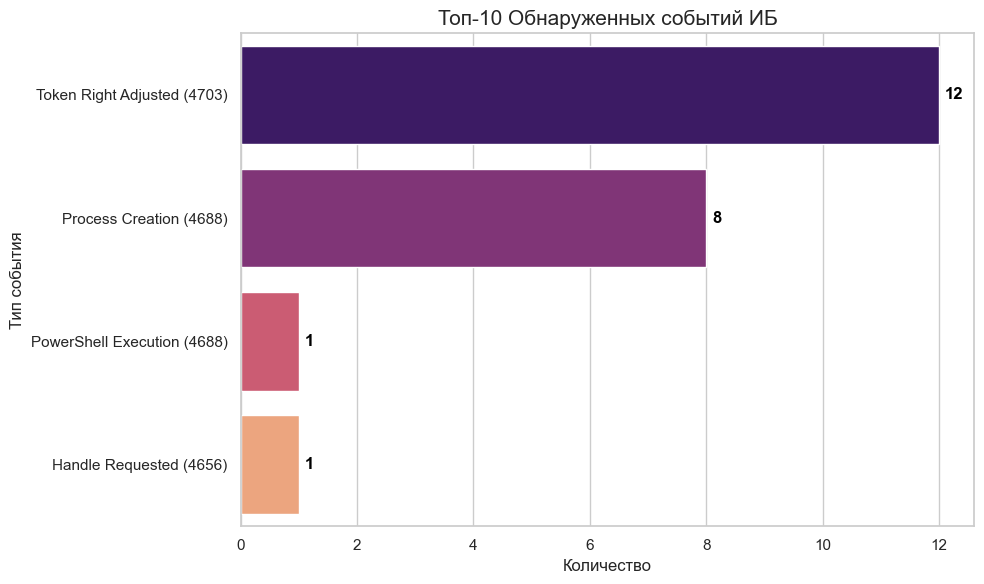

In [17]:
# Настройка стиля графиков
sns.set_theme(style="whitegrid")

input_file = 'botsv1.json'

# 1. Загрузка
full_df = load_and_normalize_data(input_file)

if full_df.empty:
    exit(1)

# 2. Анализ
print("[*] Поиск угроз Windows...")
win_threats = find_suspicious_windows_events(full_df)
print(f"    -> Найдено: {len(win_threats)}")

print("[*] Поиск аномалий DNS...")
dns_threats = find_suspicious_dns_events(full_df)
print(f"    -> Найдено: {len(dns_threats)}")

# 3. Объединение результатов
all_threats = pd.concat([win_threats, dns_threats], ignore_index=True)

# 4. Визуализация и отчет
if not all_threats.empty:
    print("\n[INFO] Статистика по типам угроз:")
    print(all_threats['Threat_Type'].value_counts())
    
    visualize_results(all_threats, top_n=10)
else:
    print("\n[OK] Подозрительных событий не обнаружено.")